In [276]:
%pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [277]:
%pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [278]:
%pip install load_dotenv

Note: you may need to restart the kernel to use updated packages.


In [279]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [280]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [281]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [282]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [283]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}?timezone=+07:00")

# Shower log

In [284]:
import pandas as pd

query = "SELECT * FROM SHOWER_LOG"
df = pd.read_sql(query, engine)

AttributeError: Unsupported argument 'timezone'

In [ ]:
df.head()

,USER_ID,DAY_ID,SHOWER_START,SHOWER_DURING,SHOWER_TEMP
0,1,1,0 days 15:00:00,long,hot
1,1,2,0 days 13:00:00,long,hot
2,1,3,0 days 08:00:00,long,warm
3,1,3,0 days 20:30:00,short,hot
4,1,4,0 days 13:00:00,long,hot


In [ ]:
print(df.describe())

       USER_ID   DAY_ID               SHOWER_START
count      8.0  8.00000                          8
mean       1.0  3.87500            0 days 11:56:15
std        0.0  2.03101  0 days 04:53:34.989558408
min        1.0  1.00000            0 days 06:15:00
25%        1.0  2.75000            0 days 07:33:45
50%        1.0  3.50000            0 days 13:00:00
75%        1.0  5.25000            0 days 13:52:30
max        1.0  7.00000            0 days 20:30:00


In [ ]:
import matplotlib.pyplot as plt

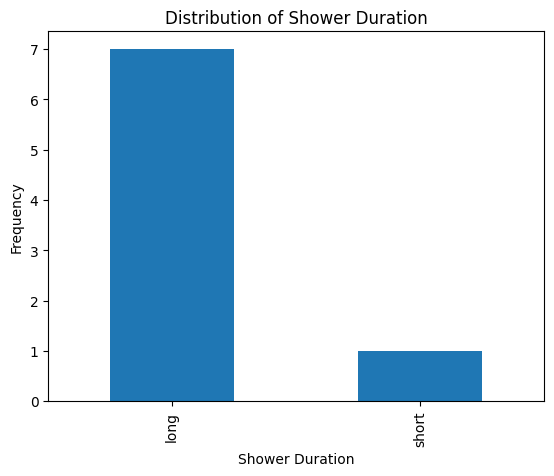

In [ ]:
df['SHOWER_DURING'].value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel("Shower Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Shower Duration")
plt.show()

# PHONE SCREEN

In [ ]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [ ]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL
0,2025-06-20,399.0,353.0
1,2025-06-21,226.0,117.0
2,2025-06-22,274.0,195.0
3,2025-06-23,300.0,206.0
4,2025-06-24,123.0,113.0


In [ ]:
print(ps[['SCREEN_TIME','SOCIAL']].describe())

       SCREEN_TIME      SOCIAL
count     6.000000    6.000000
mean    261.000000  179.500000
std      90.875739   96.804442
min     123.000000   93.000000
25%     230.500000  114.000000
50%     259.000000  156.000000
75%     293.500000  203.250000
max     399.000000  353.000000


<function matplotlib.pyplot.show(close=None, block=None)>

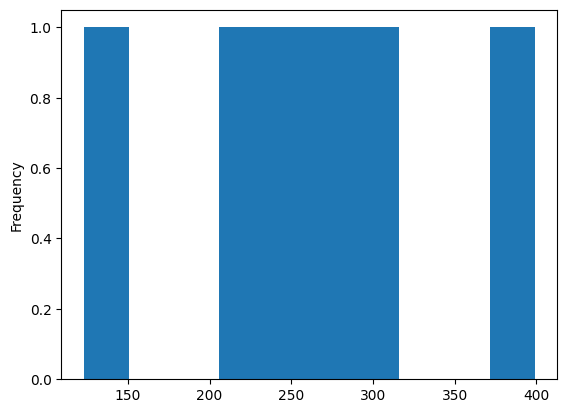

In [ ]:
ps['SCREEN_TIME'].plot.hist()
plt.show

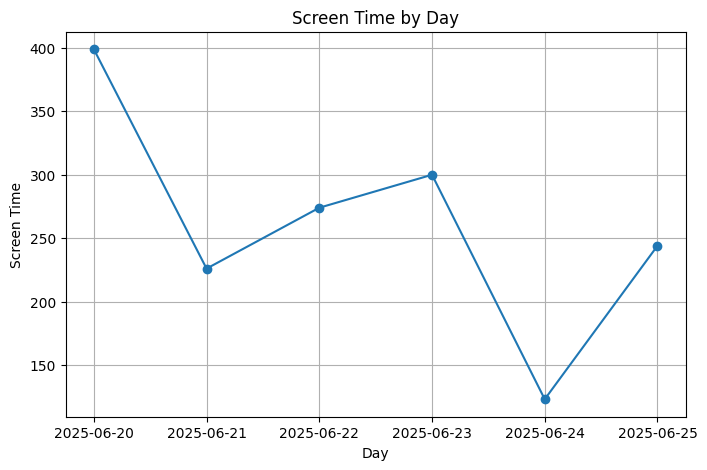

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,z_score,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,1.663496,1.663496,1.963337
1,2025-06-21,226.0,117.0,-0.421901,-0.421901,-0.707254
2,2025-06-22,274.0,195.0,0.156706,0.156706,0.175399
3,2025-06-23,300.0,206.0,0.470118,0.470118,0.299876
4,2025-06-24,123.0,113.0,-1.663496,-1.663496,-0.752518


In [ ]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107
